In [16]:
from typing import TypedDict, Literal

class State(TypedDict):
    value: int
    decision: Literal["even", "odd"]

In [17]:
def even_node(state: State):
    print("짝수!")
    print(f"{state['value']}")
    return state

def odd_node(state: State):
    print("홀수!")
    print(f"{state['value']}")
    return state

def check_condition_node(state: State) -> State:
    # print(f"{state['value']}")

    if state['value'] % 2 == 0:
        decision = "even"
    else:
        decision = "odd"

    return {"decision": decision}

In [18]:
def router(state: State) -> Literal["even", "odd"]:
    if state['decision'] == "even":
        return "even"
    else:
        return "odd"

In [19]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

graph_builder.add_node("check_condition", check_condition_node)
graph_builder.add_node("even", even_node)
graph_builder.add_node("odd", odd_node)

graph_builder.add_edge(START, "check_condition")
graph_builder.add_conditional_edges(
    "check_condition",
    router,
    {
        "even": "even",
        "odd": "odd",
    }
)
graph_builder.add_edge("even", END)
graph_builder.add_edge("odd", END)

graph = graph_builder.compile()

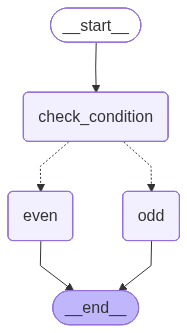

In [20]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
graph.invoke({"value": 5})

홀수!
5


{'value': 5, 'decision': 'odd'}

In [22]:
graph.invoke({"value": 6})

짝수!
6


{'value': 6, 'decision': 'even'}